# BDC 2026 - Waste Image Classification (Stacking: ConvNeXtV2-Tiny + SigLIP2) — v1

Direformat dari notebook stacking sebelumnya supaya strukturnya konsisten dengan notebook lain
di project ini (CONFIG-driven, fungsi modular per section, markdown header per bagian).

**Perubahan dari versi sebelumnya:**

1. **Data tidak lagi didownload dari Google Drive lewat `gdown`** — dihapus total. Notebook ini
   sekarang murni membaca dari direktori lokal (`CONFIG["root"]`), sama seperti notebook-notebook
   lain di project ini. Pastikan folder `BDC 2026/` (berisi `train/`, `test/`, `submission.csv`)
   sudah ada di direktori kerja sebelum menjalankan.
2. Semua parameter (path, model yang di-stack, epoch, mode K-Fold, dst.) dipindah ke satu `CONFIG` dict.
3. Deteksi kelas otomatis dari nama folder (`get_class_order`) dipakai konsisten di EDA maupun training —
   sebelumnya EDA pakai `os.listdir` mentah, training pakai `LabelEncoder` terpisah (hasil akhirnya sama,
   tapi sekarang satu sumber kebenaran).
4. Ditambahkan `evaluate_with_solution` (mengevaluasi submission akhir terhadap `solution.csv`) — konsisten
   dengan notebook single-model lain di project ini.
5. **Logika modeling & hyperparameter TIDAK diubah** — tetap 2 model (ConvNeXtV2-Tiny + SigLIP2 ViT-B/16),
   `USE_KFOLD=False` (1 split cepat, full epoch) sebagai default sesuai hasil eksperimen kamu sebelumnya,
   meta-learner Logistic Regression, dan seluruh fix yang sudah ada (OOF NaN-masking, urutan file test
   numerik, fallback PIL untuk gambar korup, dsb.) tetap dipertahankan persis.

**Requirements:**
```
pip install torch torchvision timm albumentations opencv-python pandas scikit-learn tqdm joblib matplotlib pillow
```

In [11]:
import os
from collections import Counter

import albumentations as A
import cv2
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import timm
import torch
import torch.nn as nn
from albumentations.pytorch import ToTensorV2
from PIL import Image
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

## Config

In [12]:
CONFIG = {
    "root": "BDC 2026",
    "img_size": 224,
    "batch_size": 32,
    "epochs_per_fold": 10,
    "n_splits": 5,
    # num_workers=0 -> loading data di proses utama, TIDAK spawn proses
    # tambahan. Wajib 0 di Windows + Jupyter/VS Code, karena DataLoader
    # dengan num_workers>0 di sana sering hang/deadlock diam-diam (progress
    # bar macet di 0% tanpa error). Kalau nanti pindah ke Linux/Colab,
    # boleh dinaikkan lagi (mis. 2-4) untuk loading data lebih cepat.
    "num_workers": 0,
    # False = 1 split cepat (~80/20), tapi FULL epoch -> ini yang menang di
    # eksperimen kamu sebelumnya (`siglip_vit_single-fold`, macro F1 0.978)
    # dibanding 5-fold OOF yang epoch-nya kepotong.
    # True  = 5-fold OOF penuh (lebih robust secara metodologi, ~5x lebih lama).
    "use_kfold": True,
    "seed": 42,
    "lr": 2e-5,
    "weight_decay": 1e-4,
    "norm_stats": {
        # Tiap arsitektur pretrained dengan skema normalisasi berbeda:
        "imagenet": {"mean": (0.485, 0.456, 0.406), "std": (0.229, 0.224, 0.225)},  # ConvNeXt
        "siglip": {"mean": (0.5, 0.5, 0.5), "std": (0.5, 0.5, 0.5)},                # SigLIP2 (ViT)
    },
    # 2 model yang di-stack. EfficientNet B3 sudah dikeluarkan (percobaan
    # voting sebelumnya terbukti menarik turun hasil gabungan -- macro F1-nya
    # 0.926 vs 0.97-an punya SigLIP2/ConvNeXt).
    "model_configs": [
        {"name": "convnextv2_tiny.fcmae_ft_in1k", "norm": "imagenet"},
        {"name": "vit_base_patch16_siglip_224.v2_webli", "norm": "siglip"},
    ],
    "submission_template": "BDC 2026/submission.csv",
    "submission_out": "submission_final.csv",
    "solution_csv": "solution.csv",  # opsional, untuk evaluasi lokal
    "meta_model_path": "meta_model.pkl",
    "oof_probs_path": "oof_probs_partial.npy",
    "test_probs_path": "test_probs_partial.npy",
}

## Deteksi Kelas & DataFrame

`get_class_order` membaca nama folder di `train/` dan mengurutkannya — karena foldernya sudah
diberi prefix angka (`0_Recyclable`, `1_Electronic`, `2_Organic`), hasil sort selalu benar sesuai
urutan target 0/1/2. Dipakai konsisten baik untuk EDA di bawah maupun untuk training nanti.

In [13]:
def get_class_order(config):
    """Deteksi otomatis urutan kelas dari nama folder di train/."""
    train_dir = os.path.join(config["root"], "train")
    return sorted(os.listdir(train_dir))


def build_dataframe(train_dir, class_order):
    images, labels = [], []
    for c in class_order:
        folder = os.path.join(train_dir, c)
        for img in os.listdir(folder):
            images.append(os.path.join(folder, img))
            labels.append(c)
    df = pd.DataFrame({"image": images, "label": labels})

    label2id = {name: i for i, name in enumerate(class_order)}
    df["target"] = df["label"].map(label2id)
    return df


def build_test_dataframe(config):
    test_dir = os.path.join(config["root"], "test")
    # sorted() mengurutkan nama file secara STRING (1.jpg, 10.jpg, 100.jpg, ...),
    # bukan angka -> diurutkan berdasarkan angka pada nama file supaya sinkron
    # dengan urutan id di submission.csv.
    test_images = sorted(
        os.listdir(test_dir),
        key=lambda x: int("".join(filter(str.isdigit, x)))
    )
    test_df = pd.DataFrame({"image": test_images})
    test_df["id"] = test_df["image"].apply(lambda x: int("".join(filter(str.isdigit, x))))
    return test_df

## Cek Folder

In [14]:
ROOT = CONFIG["root"]
TRAIN_DIR = os.path.join(ROOT, "train")
TEST_DIR = os.path.join(ROOT, "test")

print(os.listdir(ROOT))
print(os.listdir(TRAIN_DIR))

classes = get_class_order(CONFIG)
print("Label mapping:", {name: i for i, name in enumerate(classes)})

['solution.csv', 'submission.csv', 'test', 'train']
['0_Recyclable', '1_Electronic', '2_Organic']
Label mapping: {'0_Recyclable': 0, '1_Electronic': 1, '2_Organic': 2}


In [15]:
for c in classes:
    folder = os.path.join(TRAIN_DIR, c)
    print(c, len(os.listdir(folder)))

0_Recyclable 9547
1_Electronic 3950
2_Organic 11457


## Visualisasi Sebaran Data

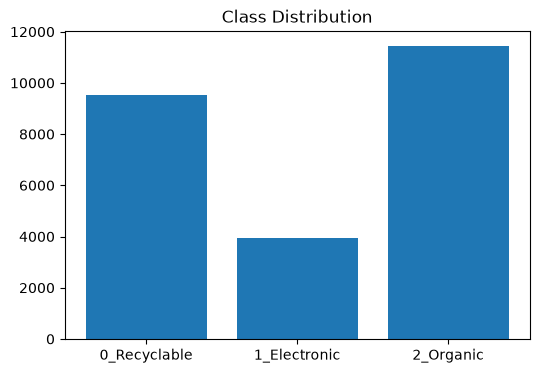

In [16]:
counts = {}

for c in classes:
    counts[c] = len(os.listdir(os.path.join(TRAIN_DIR, c)))

plt.figure(figsize=(6, 4))
plt.bar(counts.keys(), counts.values())
plt.title("Class Distribution")
plt.show()

## Sample Gambar

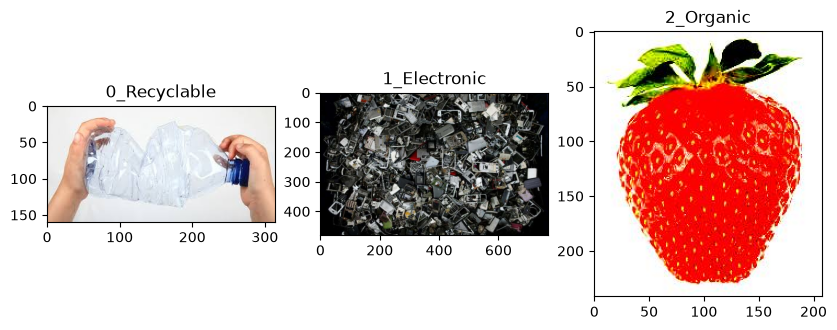

In [17]:
fig, ax = plt.subplots(1, len(classes), figsize=(10, 10))

for i, c in enumerate(classes):
    folder = os.path.join(TRAIN_DIR, c)
    img = os.listdir(folder)[0]
    path = os.path.join(folder, img)
    image = Image.open(path)
    ax[i].imshow(image)
    ax[i].set_title(c)

plt.show()

## Ukuran Gambar

Total gambar dicek: 24954
10 ukuran paling umum: [((225, 225), 3902), ((150, 150), 2660), ((275, 183), 2366), ((259, 194), 1574), ((300, 168), 844), ((183, 275), 468), ((194, 259), 340), ((276, 183), 327), ((299, 168), 315), ((284, 177), 209)]
Lebar  - min: 33, max: 8000, rata-rata: 306
Tinggi - min: 48, max: 6000, rata-rata: 252


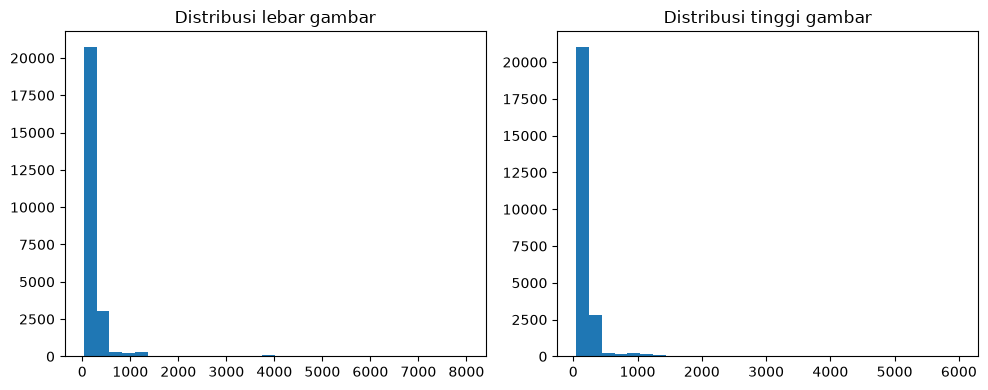

In [18]:
sizes = []

for c in classes:
    folder = os.path.join(TRAIN_DIR, c)
    for img in os.listdir(folder):
        path = os.path.join(folder, img)
        try:
            image = Image.open(path)
            sizes.append(image.size)
        except Exception:
            continue

widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

print(f"Total gambar dicek: {len(sizes)}")
print(f"10 ukuran paling umum: {Counter(sizes).most_common(10)}")
print(f"Lebar  - min: {min(widths)}, max: {max(widths)}, rata-rata: {np.mean(widths):.0f}")
print(f"Tinggi - min: {min(heights)}, max: {max(heights)}, rata-rata: {np.mean(heights):.0f}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(widths, bins=30)
plt.title("Distribusi lebar gambar")
plt.subplot(1, 2, 2)
plt.hist(heights, bins=30)
plt.title("Distribusi tinggi gambar")
plt.tight_layout()
plt.show()

## Corrupt Image

In [19]:
broken = []

for c in classes:
    folder = os.path.join(TRAIN_DIR, c)
    for img in os.listdir(folder):
        try:
            Image.open(os.path.join(folder, img))
        except Exception:
            broken.append(img)

print(len(broken))

0


## Dataset (Train/Valid) & Test

In [20]:
class WasteDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_path = row["image"]
        label = row["target"]

        image = cv2.imread(image_path)
        if image is None:
            # cv2.imread bisa gagal (return None) untuk sebagian file walau
            # lolos cek PIL sebelumnya. Fallback ke PIL supaya training
            # tidak crash di tengah epoch.
            image = np.array(Image.open(image_path).convert("RGB"))
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform is not None:
            image = self.transform(image=image)["image"]

        return image, label


class TestDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_name = self.df.loc[idx, "image"]
        image_path = os.path.join(self.image_dir, image_name)

        image = cv2.imread(image_path)
        if image is None:
            # Fallback ke PIL supaya inference tidak crash di tengah jalan.
            image = np.array(Image.open(image_path).convert("RGB"))
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image=image)["image"]

        return image, image_name

## Transform per Arsitektur

Tiap arsitektur pretrained dengan skema normalisasi berbeda: ConvNeXt dilatih di ImageNet (mean/std
ImageNet), SigLIP2 dilatih kontrastif image-text (skala `[-1, 1]`, mean=std=0.5). `norm_type` per
model diambil dari `CONFIG["model_configs"]`, mapping mean/std-nya dari `CONFIG["norm_stats"]`.

In [21]:
def get_transforms(img_size, norm_type, config):
    stats = config["norm_stats"][norm_type]

    train_transform = A.Compose([
        A.Resize(img_size, img_size),
        A.HorizontalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=20, p=0.5),
        A.Normalize(mean=stats["mean"], std=stats["std"]),
        ToTensorV2(),
    ])

    valid_transform = A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=stats["mean"], std=stats["std"]),
        ToTensorV2(),
    ])

    return train_transform, valid_transform

## K-Fold Split (dipakai sama untuk semua model)

`skf` (dengan `random_state` yang sama) dipakai ulang persis sama untuk SEMUA arsitektur, supaya
pembagian fold-nya konsisten antar model — penting supaya OOF prediction antar model bisa digabung
untuk baris yang sama saat melatih meta-learner. `get_fold_splits` mengembalikan seluruh fold kalau
`CONFIG["use_kfold"]=True`, atau cuma split pertama (dilatih full epoch) kalau `False`.

In [22]:
def get_skf(config):
    return StratifiedKFold(n_splits=config["n_splits"], shuffle=True, random_state=config["seed"])


def get_fold_splits(df, skf, use_kfold):
    all_splits = list(skf.split(df, df["target"]))
    if use_kfold:
        return all_splits  # semua fold dipakai (OOF penuh)
    return all_splits[:1]  # cuma split pertama, tapi dilatih FULL epoch

## Device

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

cuda
NVIDIA GeForce RTX 3060


## Training & Validasi (fungsi generic, dipakai semua model)

In [24]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0
    preds, labels = [], []

    progress = tqdm(loader)
    for images, target in progress:
        images = images.to(device)
        target = target.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        prediction = torch.argmax(outputs, dim=1)
        preds.extend(prediction.cpu().numpy())
        labels.extend(target.cpu().numpy())
        progress.set_description(f"Loss {loss.item():.4f}")

    epoch_loss = running_loss / len(loader)
    epoch_f1 = f1_score(labels, preds, average="macro")
    return epoch_loss, epoch_f1

In [25]:
@torch.no_grad()
def valid_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0
    preds, labels = [], []

    for images, target in loader:
        images = images.to(device)
        target = target.to(device)

        outputs = model(images)
        loss = criterion(outputs, target)
        running_loss += loss.item()

        prediction = torch.argmax(outputs, 1)
        preds.extend(prediction.cpu().numpy())
        labels.extend(target.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_f1 = f1_score(labels, preds, average="macro")
    return epoch_loss, epoch_f1

## Class Weight Helper

In [26]:
def make_class_weights(df_fold, n_classes, device):
    counts = df_fold["target"].value_counts().reindex(range(n_classes), fill_value=0).values.astype(float)
    counts = np.clip(counts, 1, None)  # hindari div-by-zero kalau ada kelas kosong di 1 fold
    weights = counts.sum() / (n_classes * counts)
    return torch.tensor(weights, dtype=torch.float32).to(device)

## Pipeline OOF K-Fold per Model

In [27]:
def run_kfold_oof(model_name, norm_type, df, test_df, test_image_dir, skf, device, config):
    train_transform, valid_transform = get_transforms(config["img_size"], norm_type, config)

    n_train = len(df)
    n_classes = df["target"].nunique()
    n_test = len(test_df)

    splits = get_fold_splits(df, skf, config["use_kfold"])
    n_folds_used = len(splits)

    # oof_probs: NaN untuk baris yang tidak pernah masuk valid set (terjadi
    # kalau use_kfold=False, karena cuma 1/n_splits data yang jadi valid).
    # Baris ber-NaN otomatis di-drop sebelum melatih meta-learner.
    oof_probs = np.full((n_train, n_classes), np.nan)
    test_probs_per_fold = np.zeros((n_folds_used, n_test, n_classes))

    safe_name = model_name.replace("/", "_")

    test_dataset = TestDataset(test_df, image_dir=test_image_dir, transform=valid_transform)
    test_loader = DataLoader(test_dataset, batch_size=config["batch_size"], shuffle=False, num_workers=config["num_workers"], pin_memory=True)

    for fold, (train_idx, valid_idx) in enumerate(splits):
        print(f"\n{'=' * 60}")
        print(f"{model_name} | Fold {fold + 1}/{n_folds_used}")
        print(f"{'=' * 60}")

        train_df_fold = df.iloc[train_idx].reset_index(drop=True)
        valid_df_fold = df.iloc[valid_idx].reset_index(drop=True)

        train_dataset = WasteDataset(train_df_fold, transform=train_transform)
        valid_dataset = WasteDataset(valid_df_fold, transform=valid_transform)

        train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True, num_workers=config["num_workers"], pin_memory=True)
        valid_loader = DataLoader(valid_dataset, batch_size=config["batch_size"], shuffle=False, num_workers=config["num_workers"], pin_memory=True)

        model = timm.create_model(model_name, pretrained=True, num_classes=n_classes).to(device)

        weights = make_class_weights(train_df_fold, n_classes, device)
        criterion = nn.CrossEntropyLoss(weight=weights)
        optimizer = torch.optim.AdamW(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config["epochs_per_fold"])

        best_f1 = 0
        ckpt_path = f"{safe_name}_fold{fold}.pth"

        for epoch in range(config["epochs_per_fold"]):
            train_loss, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, device)
            valid_loss, valid_f1 = valid_one_epoch(model, valid_loader, criterion, device)
            scheduler.step()

            print(f"\nEpoch {epoch + 1}/{config['epochs_per_fold']}")
            print(f"Train Loss : {train_loss:.4f} | Train F1 : {train_f1:.4f}")
            print(f"Valid Loss : {valid_loss:.4f} | Valid F1 : {valid_f1:.4f}")

            # simpan checkpoint HANYA saat membaik (bukan tiap epoch)
            if valid_f1 > best_f1:
                best_f1 = valid_f1
                torch.save(model.state_dict(), ckpt_path)
                print(f"Model terbaik disimpan (Valid F1: {best_f1:.4f})")

        # muat balik checkpoint TERBAIK fold ini sebelum ambil OOF & test prob
        model.load_state_dict(torch.load(ckpt_path, map_location=device))
        model.eval()

        # -- OOF probabilities untuk baris valid fold/split ini --
        fold_probs = []
        with torch.no_grad():
            for images, _ in valid_loader:
                images = images.to(device)
                probs = torch.softmax(model(images), dim=1)
                fold_probs.append(probs.cpu().numpy())
        oof_probs[valid_idx] = np.concatenate(fold_probs, axis=0)

        # -- Prediksi ke test set pakai model fold/split ini --
        fold_test_probs = []
        with torch.no_grad():
            for images, _ in test_loader:
                images = images.to(device)
                probs = torch.softmax(model(images), dim=1)
                fold_test_probs.append(probs.cpu().numpy())
        test_probs_per_fold[fold] = np.concatenate(fold_test_probs, axis=0)

        print(f"Fold {fold + 1} selesai. Best Valid F1: {best_f1:.4f}")

    print(f"\n{'=' * 60}")
    print(f"{model_name} SELESAI")
    print(f"{'=' * 60}")

    # macro F1 OOF cuma dihitung dari baris yang punya prediksi OOF
    valid_mask = ~np.isnan(oof_probs).any(axis=1)
    oof_preds = oof_probs[valid_mask].argmax(axis=1)
    oof_f1 = f1_score(df.loc[valid_mask, "target"], oof_preds, average="macro")
    print(f"OOF macro F1 ({valid_mask.sum()} baris tervalidasi): {oof_f1:.4f}")

    class_order = get_class_order(config)
    print(f"\n=== Classification Report OOF ({model_name}) ===")
    print(classification_report(df.loc[valid_mask, "target"], oof_preds, target_names=class_order))

    test_probs = test_probs_per_fold.mean(axis=0)  # bagging antar fold/split
    return oof_probs, test_probs, valid_mask

## Jalankan Training Semua Model

In [28]:
def run_all_models(config, df, test_df, skf, device):
    oof_probs_list = []
    test_probs_list = []
    valid_mask_list = []
    model_names = []

    test_dir = os.path.join(config["root"], "test")

    for cfg in config["model_configs"]:
        oof_probs, test_probs, valid_mask = run_kfold_oof(
            model_name=cfg["name"],
            norm_type=cfg["norm"],
            df=df,
            test_df=test_df,
            test_image_dir=test_dir,
            skf=skf,
            device=device,
            config=config,
        )
        oof_probs_list.append(oof_probs)
        test_probs_list.append(test_probs)
        valid_mask_list.append(valid_mask)
        model_names.append(cfg["name"])

        # simpan tiap kali selesai 1 model, supaya kalau sesi putus di
        # tengah jalan, model yang sudah selesai tidak hilang percuma
        np.save(config["oof_probs_path"], np.array(oof_probs_list, dtype=object), allow_pickle=True)
        np.save(config["test_probs_path"], np.array(test_probs_list, dtype=object), allow_pickle=True)

    return oof_probs_list, test_probs_list, valid_mask_list, model_names

## Meta-Learner (Stacking)

In [29]:
def train_meta_learner(config, df, oof_probs_list, valid_mask_list, model_names):
    # Kalau use_kfold=False, tiap baris train cuma punya OOF prediction dari
    # model yang memang "jatah" valid split-nya. Ambil irisan baris yang
    # tervalidasi oleh SEMUA model (kalau use_kfold=True ini otomatis 100%
    # baris, karena OOF penuh).
    common_valid_mask = np.logical_and.reduce(valid_mask_list)
    print(f"Baris dipakai untuk melatih meta-learner: {common_valid_mask.sum()} dari {len(df)}")

    X_meta_train = np.concatenate([oof[common_valid_mask] for oof in oof_probs_list], axis=1)
    y_meta_train = df.loc[common_valid_mask, "target"].values

    meta_model = LogisticRegression(max_iter=1000)

    # Sanity check: cross-validate meta-learner ITU SENDIRI supaya tidak
    # menipu diri sendiri kalau meta-learner overfit ke OOF probabilities.
    cv_scores = cross_val_score(meta_model, X_meta_train, y_meta_train, cv=5, scoring="f1_macro")
    print(f"Macro F1 meta-learner (5-fold CV di atas OOF probs): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

    meta_model.fit(X_meta_train, y_meta_train)
    joblib.dump(meta_model, config["meta_model_path"])

    print("\nMacro F1 tiap base model secara individu (OOF):")
    for name, oof in zip(model_names, oof_probs_list):
        mask = ~np.isnan(oof).any(axis=1)
        f1 = f1_score(df.loc[mask, "target"], oof[mask].argmax(axis=1), average="macro")
        print(f"  {name}: {f1:.4f} ({mask.sum()} baris)")

    return meta_model, X_meta_train, y_meta_train

## Prediksi Akhir & Submission

In [30]:
def predict_and_submit(config, meta_model, test_df, test_probs_list):
    X_meta_test = np.concatenate(test_probs_list, axis=1)
    final_preds = meta_model.predict(X_meta_test)

    pred_map = dict(zip(test_df["id"], final_preds))

    submission = pd.read_csv(config["submission_template"])
    submission["predicted"] = submission["id"].map(pred_map)
    assert submission["predicted"].isna().sum() == 0, "Ada id yang tidak ter-mapping, cek ulang!"
    submission["predicted"] = submission["predicted"].astype(int)

    submission.to_csv(config["submission_out"], index=False)
    print(f"Submission disimpan ke: {config['submission_out']}")
    return submission

## Evaluasi (OOF & solution.csv)

`evaluate_oof` mengecek performa meta-learner di atas data train (OOF). `evaluate_with_solution`
membandingkan submission akhir dengan `solution.csv` — label hasil labeling manual kamu sendiri
untuk data test — konsisten dengan notebook single-model lain di project ini.

In [31]:
def evaluate_oof(meta_model, X_meta_train, y_meta_train):
    oof_meta_preds = meta_model.predict(X_meta_train)
    print("=== Classification Report OOF (meta-learner) ===")
    print(classification_report(y_meta_train, oof_meta_preds, digits=3))


def evaluate_with_solution(config, submission):
    if not os.path.exists(config["solution_csv"]):
        print(f"\n({config['solution_csv']} tidak ditemukan, skip evaluasi lokal)")
        return

    class_order = get_class_order(config)
    gt = pd.read_csv(config["solution_csv"])
    gt["predicted"] = gt["predicted"].fillna(0).astype(int)  # NaN = kelas 0 (Recyclable)
    gt = gt.rename(columns={"predicted": "true_label"})

    eval_df = submission.merge(gt, on="id", how="left")
    y_true = eval_df["true_label"]
    y_pred = eval_df["predicted"]

    print("\n=== Evaluasi vs solution.csv ===")
    print("F1 Macro:", f1_score(y_true, y_pred, average="macro"))
    print()
    print(classification_report(y_true, y_pred, target_names=class_order))
    print()
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))

## Run

Melatih kedua model (bisa berjam-jam tergantung `CONFIG["use_kfold"]` — jalankan per sesi kalau perlu,
progress tiap model otomatis disimpan ke `.npy` lewat `run_all_models`), lalu melatih meta-learner,
membuat submission akhir, dan mengevaluasinya.

In [32]:
class_order = get_class_order(CONFIG)

train_dir = os.path.join(CONFIG["root"], "train")
df = build_dataframe(train_dir, class_order)
test_df = build_test_dataframe(CONFIG)

skf = get_skf(CONFIG)

oof_probs_list, test_probs_list, valid_mask_list, model_names = run_all_models(CONFIG, df, test_df, skf, device)

meta_model, X_meta_train, y_meta_train = train_meta_learner(CONFIG, df, oof_probs_list, valid_mask_list, model_names)

submission = predict_and_submit(CONFIG, meta_model, test_df, test_probs_list)

evaluate_oof(meta_model, X_meta_train, y_meta_train)
evaluate_with_solution(CONFIG, submission)

C:\Users\MyPC PRO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)



convnextv2_tiny.fcmae_ft_in1k | Fold 1/5


Loss 0.0265: 100%|██████████| 624/624 [06:14<00:00,  1.67it/s]



Epoch 1/10
Train Loss : 0.2041 | Train F1 : 0.9321
Valid Loss : 0.0668 | Valid F1 : 0.9804
Model terbaik disimpan (Valid F1: 0.9804)


Loss 0.3014: 100%|██████████| 624/624 [06:10<00:00,  1.68it/s]


...


Epoch 8/10
Train Loss : 0.0052 | Train F1 : 0.9980
Valid Loss : 0.0288 | Valid F1 : 0.9911
Model terbaik disimpan (Valid F1: 0.9911)


Loss 0.0008: 100%|██████████| 624/624 [07:03<00:00,  1.47it/s]



Epoch 9/10
Train Loss : 0.0018 | Train F1 : 0.9995
Valid Loss : 0.0313 | Valid F1 : 0.9910


Loss 0.0001: 100%|██████████| 624/624 [07:03<00:00,  1.47it/s]



Epoch 10/10
Train Loss : 0.0019 | Train F1 : 0.9993
Valid Loss : 0.0296 | Valid F1 : 0.9907
Fold 5 selesai. Best Valid F1: 0.9911

vit_base_patch16_siglip_224.v2_webli SELESAI
OOF macro F1 (24954 baris tervalidasi): 0.9919

=== Classification Report OOF (vit_base_patch16_siglip_224.v2_webli) ===
              precision    recall  f1-score   support

0_Recyclable       0.99      0.99      0.99      9547
1_Electronic       1.00      0.99      0.99      3950
   2_Organic       0.99      0.99      0.99     11457

    accuracy                           0.99     24954
   macro avg       0.99      0.99      0.99     24954
weighted avg       0.99      0.99      0.99     24954

Baris dipakai untuk melatih meta-learner: 24954 dari 24954
Macro F1 meta-learner (5-fold CV di atas OOF probs): 0.9923 (+/- 0.0017)

Macro F1 tiap base model secara individu (OOF):
  convnextv2_tiny.fcmae_ft_in1k: 0.9873 (24954 baris)
  vit_base_patch16_siglip_224.v2_webli: 0.9919 (24954 baris)
Submission disimpan ke: s